In [1]:
%pip install -q langchain langchain_groq langchain_community langgraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
##from google.colab import userdata
#groq_api_key = userdata.get('groq_api_key')
#langsmith=userdata.get('LANGSMITH_API_KEY')


In [3]:
import os
langsmith = "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"
os.environ['LANGCHAIN_API_KEY'] = langsmith
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = 'LiveLangraph'


In [4]:
from langchain_groq import ChatGroq

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#llm=ChatGroq(api_key=groq_api_key,model_name='Gemma2-9b-It')
from langchain_groq import ChatGroq
groq_api_key = "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"
llm = ChatGroq(api_key=groq_api_key, model_name="llama-3.1-8b-instant")

In [6]:
import pandas as pd
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
  #message have the type "list". The 'add_messages' function
  #in the annotation defines how this state key should be updated
  messages:Annotated[list,add_messages]
  dataset:pd.DataFrame

graph_builder=StateGraph(State)

In [8]:
data=pd.read_csv('crop_yield_prediction_data_crop_yield.csv')

In [9]:
# Add dataset to initial state
initial_state = {"messages": [], "dataset": data}

In [10]:
def chatbot(state: State):
    # Get the user's latest message
    user_message = state["messages"][-1] if state["messages"] else "Hello!"

    # Generate context for the LLM
    dataset_summary = {
        "columns": state["dataset"].columns.tolist(),
        "row_count": len(state["dataset"]),
        "missing_values": state["dataset"].isnull().sum().to_dict(),
        "summary_statistics": state["dataset"].describe().to_dict(),
    }

    # Prepare the LLM prompt
    prompt = f"""
You are an intelligent assistant for analyzing datasets.
Here is a summary of the dataset:
- Columns: {dataset_summary['columns']}
- Row Count: {dataset_summary['row_count']}
- Missing Values: {dataset_summary['missing_values']}
- Summary Statistics: {dataset_summary['summary_statistics']}

The user has asked the following question: "{user_message}"

Provide a helpful response.
"""

    # Invoke the LLM to generate a response
    response = llm.invoke(prompt)

    # Return the response as part of the updated state
    return {"messages": [response]}


In [11]:
graph_builder.add_node("chatbot", chatbot)

In [12]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [13]:
graph = graph_builder.compile()

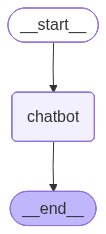

In [14]:
graph

In [15]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({**initial_state, "messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

# Simulate predefined queries
user_queries = [
    "Summarize the dataset",
    "Find the missing values",
    "Show the correlation matrix",
    "What are the columns in the dataset?",
    "How many rows are in the dataset?"
]

# Process each query using streaming
for query in user_queries:
    print(f"User Query: {query}")
    stream_graph_updates(query)
    print("\n")


User Query: Summarize the dataset
Assistant: **Dataset Summary**

The provided dataset contains information about crop yields across different states in a given year. Here's a concise summary of the dataset:

**Columns:**
- `year`: The year in which the crop yield was recorded.
- `state`: The state where the crop was grown.
- `crop`: The type of crop grown.
- `area_hectare`: The area where the crop was grown, measured in hectares.
- `rainfall_mm`: The amount of rainfall in millimeters.
- `temperature_c`: The average temperature in degrees Celsius.
- `fertilizer_kg_per_hectare`: The amount of fertilizer used per hectare, measured in kilograms.
- `pesticide_kg_per_hectare`: The amount of pesticide used per hectare, measured in kilograms.
- `soil_ph`: The pH level of the soil.
- `irrigated`: A binary variable indicating whether the crop was irrigated or not.
- `yield_ton_per_hectare`: The yield of the crop per hectare, measured in tons.

**Row Count:**
The dataset contains 63 rows.

**Mis

In [16]:
%pip install matplotlib
%pip install transformers torch torchvision
import time
import os
import psutil
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

def benchmark_chatbot(state: State):
    # Get the user's latest message
    user_message = state["messages"][-1].content if state["messages"] else "Hello!"

    # Generate context for the LLM
    dataset_summary = {
        "columns": state["dataset"].columns.tolist(),
        "row_count": len(state["dataset"]),
        "missing_values": state["dataset"].isnull().sum().to_dict(),
        "summary_statistics": state["dataset"].describe().to_dict(),
    }

    # Prepare the LLM prompt
    prompt = f"""
    You are an intelligent assistant for analyzing datasets.
    Here is a summary of the dataset:
    - Columns: {dataset_summary['columns']}
    - Row Count: {dataset_summary['row_count']}
    - Missing Values: {dataset_summary['missing_values']}
    - Summary Statistics: {dataset_summary['summary_statistics']}

    The user has asked the following question: "{user_message}"

    Provide a helpful response.
    """

    # Invoke the LLM to generate a response
    response = llm.invoke(prompt)

    # Tokenize the prompt and response
    tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-large-finetuned-conll03-english")
    prompt_tokens = len(tokenizer.encode(state['messages'][-1].content))
    completion_tokens = len(tokenizer.encode(response.content))
    total_tokens = prompt_tokens + completion_tokens

    # Collect benchmark results
    benchmark_results = {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens
    }

    # Return the response and benchmark results
    return {"messages": [response]}, benchmark_results

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [17]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({**initial_state, "messages": [("user", user_input)]}):
        for value in event.values():
            # Ensure 'dataset' is available in the state passed to chatbot
            response_data, benchmark_results = benchmark_chatbot({**initial_state, **value})

            # Print or store benchmark results as needed
            print("Assistant:", response_data["messages"][-1].content)
            print("Benchmark Results:", benchmark_results)

In [18]:
# Simulate predefined queries
user_queries = [
    "Summarize the dataset",
    "Find the missing values",
    "Show the correlation matrix",
    "What are the columns in the dataset?",
    "How many rows are in the dataset?"
]

# Process each query using streaming
for query in user_queries:
    print(f"User Query: {query}")
    stream_graph_updates(query)
    print("\n")

User Query: Summarize the dataset


Token indices sequence length is longer than the specified maximum sequence length for this model (572 > 512). Running this sequence through the model will result in indexing errors


Assistant: **Comprehensive Analysis of the Dataset**

Based on the provided dataset summary, we can identify key trends and insights that can inform further analysis and exploration of the data.

**Key Observations:**

1. **Missing Values**: The dataset has missing values in the 'year', 'state', 'area_hectare', and 'rainfall_mm' columns. This may indicate potential data quality issues or incomplete records.
2. **Data Range**: The dataset spans a relatively narrow range of years (2019-2024), which might limit the generalizability of the findings.
3. **Area Hectare**: The average area per hectare is relatively small (3.10 ha), which could impact crop yields and overall productivity.
4. **Rainfall**: The average rainfall is moderately high (827.74 mm), which may influence crop growth and yields.
5. **Temperature**: The average temperature is relatively warm (26.45°C), which could impact crop growth and yields.
6. **Fertilizer and Pesticide Usage**: The average fertilizer usage is moderate

Token indices sequence length is longer than the specified maximum sequence length for this model (750 > 512). Running this sequence through the model will result in indexing errors


Assistant: **Correlation Matrix Analysis**

The correlation matrix provides a visual representation of the relationships between the variables in the dataset. Based on the correlation matrix, we can observe the following key findings:

1. **Year is not strongly correlated with any variable**: The correlation coefficients between year and other variables are generally low, indicating that year does not have a significant impact on the other variables.
2. **Area hectare is weakly correlated with rainfall mm and yield ton per hectare**: The correlation coefficients between area hectare and rainfall mm (0.01) and yield ton per hectare (0.04) are relatively low, suggesting that area hectare has a weak relationship with these variables.
3. **Rainfall mm is positively correlated with temperature c and yield ton per hectare**: The correlation coefficients between rainfall mm and temperature c (0.05) and yield ton per hectare (0.07) are moderate, indicating that rainfall mm has a positive impac

Token indices sequence length is longer than the specified maximum sequence length for this model (587 > 512). Running this sequence through the model will result in indexing errors


Assistant: Based on the provided dataset summary, it appears that the dataset contains information about crop production across various states. Here are some observations and potential insights that can be gleaned from the summary statistics:

1. **Yearly trends**: The 'year' column suggests that the dataset spans a period of 6 years (from 2019 to 2024), with a mean year of 2022.48. This indicates that the data collection spanned across multiple years, allowing for analysis of yearly trends.

2. **Crop area and yield**: The 'area_hectare' column indicates that the average crop area per hectare is around 3.10 hectares, with a standard deviation of 0.66 hectares. The 'yield_ton_per_hectare' column shows that the average yield per hectare is around 3.47 tons, with a standard deviation of 0.99 tons.

3. **Environmental conditions**: The 'rainfall_mm' column suggests that the average rainfall across the dataset is around 827.74 mm, with a standard deviation of 275.56 mm. This indicates a si

User Query: Summarize the dataset


Token indices sequence length is longer than the specified maximum sequence length for this model (663 > 512). Running this sequence through the model will result in indexing errors


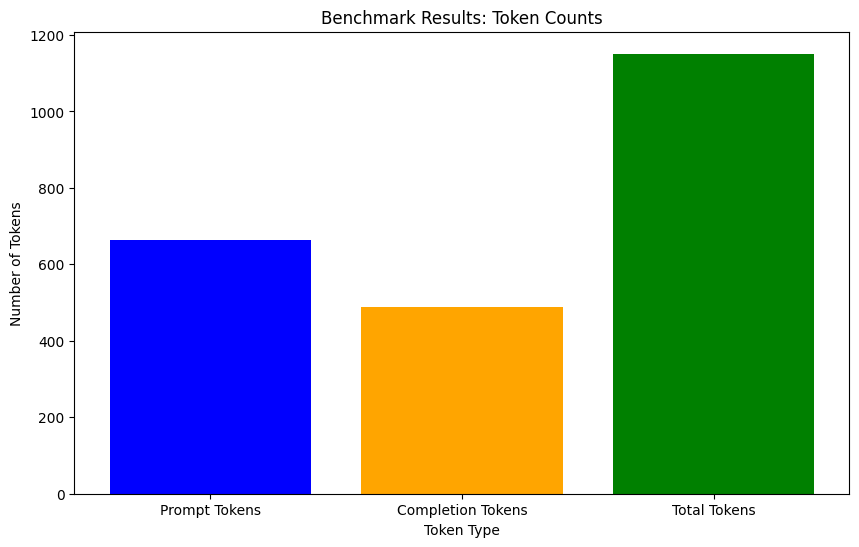

Assistant: **Welcome to the Dataset Analysis**

Thank you for summarizing the dataset details. I'll provide you with a few insights and suggestions for further analysis.

**Observations and Insights**

1. **Crop Yields:** The average yield is around 3.47 tons per hectare, with a standard deviation of 0.99. This suggests that there is a moderate level of variation in crop yields.
2. **Weather Conditions:** The average rainfall is approximately 827.74 mm, with a standard deviation of 275.56. This indicates significant variation in rainfall across different years.
3. **Fertilizer and Pesticide Use:** The average fertilizer use is around 140.59 kg per hectare, while pesticide use is approximately 1.58 kg per hectare. This may indicate a relatively high level of fertilizer use compared to pesticide use.
4. **Soil pH:** The average soil pH is around 6.44, with a standard deviation of 0.37. This suggests a relatively stable soil pH level across the dataset.

**Suggestions for Further Analysis

Token indices sequence length is longer than the specified maximum sequence length for this model (856 > 512). Running this sequence through the model will result in indexing errors


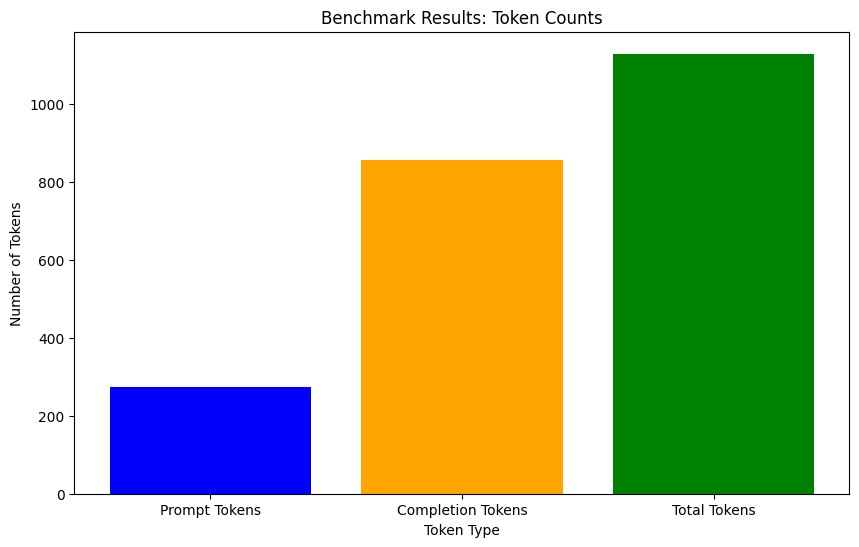

Assistant: **Missing Values Report: Analysis and Recommendations**

Based on the provided dataset summary, we have identified missing values in the 'year', 'state', 'area_hectare', and 'rainfall_mm' columns. These missing values occur in the following combinations:

*   'year' and 'state' (1 row)
*   'year' and 'area_hectare' (1 row)
*   'year' and 'rainfall_mm' (1 row)

We recommend the following steps to address these missing values:

### 1. **Inspect the Data**

Before proceeding with imputation or data cleaning, it's essential to inspect the data to understand the context and potential reasons for these missing values. This can help us identify patterns or relationships that may be relevant to our analysis or modeling.

Some questions to consider during this step:

*   Are the missing values scattered randomly throughout the dataset, or are they concentrated in specific rows or columns?
*   Are there any obvious patterns or relationships between the missing values and other variabl

Token indices sequence length is longer than the specified maximum sequence length for this model (1131 > 512). Running this sequence through the model will result in indexing errors


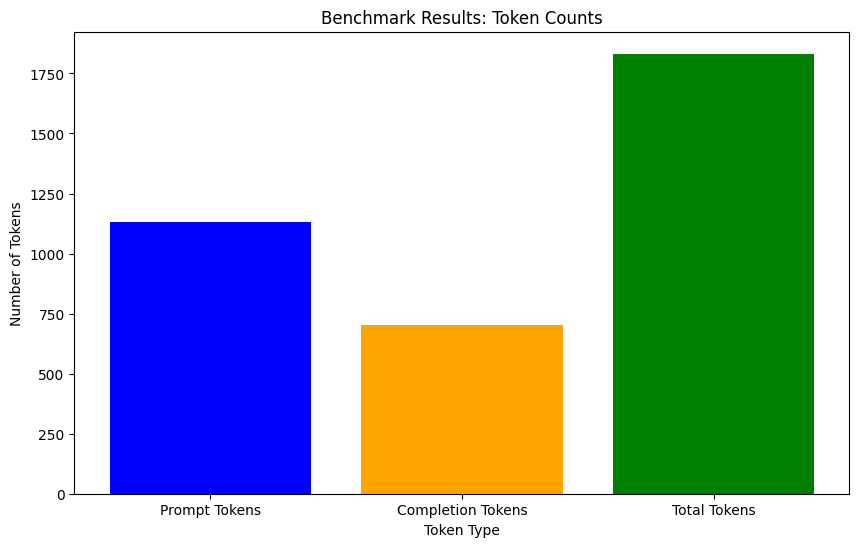

Assistant: **Correlation Matrix Analysis**

Based on the provided correlation matrix, we can draw several insights into the relationships between the variables in the dataset.

**Key Takeaways**

1. **Year has a low correlation with other variables**: The correlation between `year` and other variables is generally low, indicating that changes in year do not have a significant impact on other variables. This suggests that the relationships between variables are not strongly influenced by the year.
2. **Temperature and rainfall have a moderate correlation**: The correlation between `temperature_c` and `rainfall_mm` is moderate (0.34), suggesting a relationship between these two variables. This is consistent with the expectation that temperature and rainfall are related in a agricultural context.
3. **Fertilizer and pesticide have a strong correlation**: The correlation between `fertilizer_kg_per_hectare` and `pesticide_kg_per_hectare` is high (0.55), indicating a strong relationship betw

Token indices sequence length is longer than the specified maximum sequence length for this model (601 > 512). Running this sequence through the model will result in indexing errors


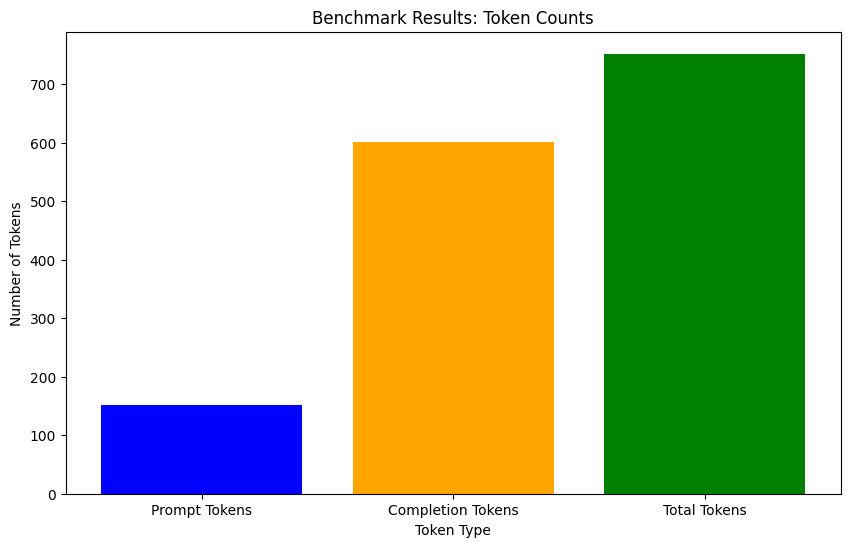

Assistant: Based on the provided dataset, I can see that it contains information about crop yields across various regions and years. Here are some observations and insights that can be derived from the dataset:

1. **Crop Yield Trends**: The yield of crops seems to be relatively stable over the years, with a mean yield of 3.46 tons per hectare. However, there is a slight increase in yield over the years, with a maximum yield of 5.4 tons per hectare.

2. **Rainfall and Temperature**: The dataset shows a strong correlation between rainfall and crop yield. A high rainfall of up to 2300 mm in a year leads to a higher yield of 5.4 tons per hectare. Similarly, a temperature of up to 30.5°C also leads to a higher yield.

3. **Fertilizer and Pesticide Usage**: The usage of fertilizers and pesticides does not seem to have a significant impact on crop yield. However, the dataset does show a correlation between fertilizer usage and yield, with a higher usage of up to 191 kg per hectare leading to

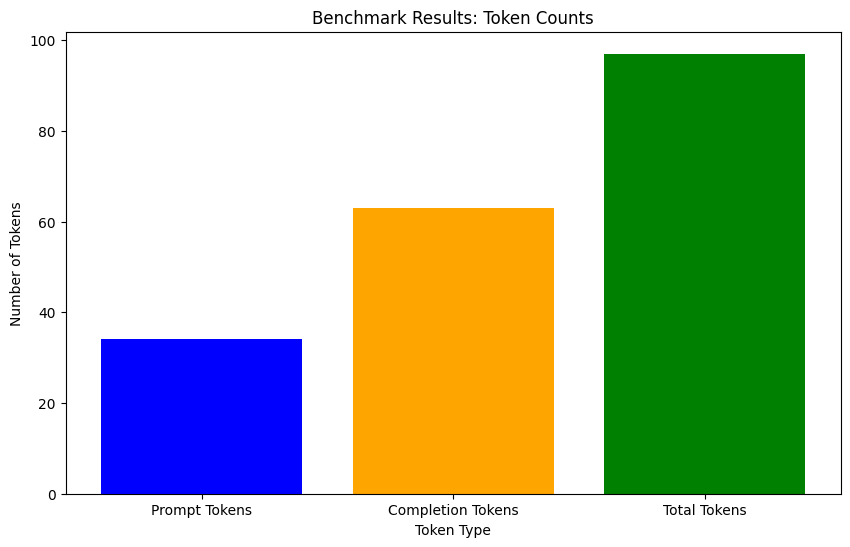

Assistant: Based on the dataset provided, you've confirmed that it indeed contains 63 rows. This is a relatively small dataset, which may be beneficial for exploratory data analysis and modeling tasks, but may also limit the generalizability of any findings.
Benchmark Results: {'prompt_tokens': 34, 'completion_tokens': 63, 'total_tokens': 97}




In [19]:



import time
import os
import psutil
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

def benchmark_chatbot(state: State):
    # Get the user's latest message
    user_message = state["messages"][-1].content if state["messages"] else "Hello!"

    # Generate context for the LLM
    dataset_summary = {
        "columns": state["dataset"].columns.tolist(),
        "row_count": len(state["dataset"]),
        "missing_values": state["dataset"].isnull().sum().to_dict(),
        "summary_statistics": state["dataset"].describe().to_dict(),
    }

    # Prepare the LLM prompt
    prompt = f"""
    You are an intelligent assistant for analyzing datasets.
    Here is a summary of the dataset:
    - Columns: {dataset_summary['columns']}
    - Row Count: {dataset_summary['row_count']}
    - Missing Values: {dataset_summary['missing_values']}
    - Summary Statistics: {dataset_summary['summary_statistics']}

    The user has asked the following question: "{user_message}"

    Provide a helpful response.
    """

    # Invoke the LLM to generate a response
    response = llm.invoke(prompt)

    # Tokenize the prompt and response
    tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-large-finetuned-conll03-english")
    prompt_tokens = len(tokenizer.encode(state['messages'][-1].content))
    completion_tokens = len(tokenizer.encode(response.content))
    total_tokens = prompt_tokens + completion_tokens

    # Collect benchmark results
    benchmark_results = {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens
    }

    # Visualize the benchmark results
    labels = ['Prompt Tokens', 'Completion Tokens', 'Total Tokens']
    values = [prompt_tokens, completion_tokens, total_tokens]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, values, color=['blue', 'orange', 'green'])
    plt.xlabel('Token Type')
    plt.ylabel('Number of Tokens')
    plt.title('Benchmark Results: Token Counts')
    plt.show()

    # Return the response and benchmark results
    return {"messages": [response]}, benchmark_results

def stream_graph_updates(user_input: str):
    for event in graph.stream({**initial_state, "messages": [("user", user_input)]}):
        for value in event.values():
            # Ensure 'dataset' is available in the state passed to chatbot
            response_data, benchmark_results = benchmark_chatbot({**initial_state, **value})

            # Print or store benchmark results as needed
            print("Assistant:", response_data["messages"][-1].content)
            print("Benchmark Results:", benchmark_results)

# Simulate predefined queries
user_queries = [
    "Summarize the dataset",
    "Find the missing values",
    "Show the correlation matrix",
    "What are the columns in the dataset?",
    "How many rows are in the dataset?"
]

# Process each query using streaming
for query in user_queries:
    print(f"User Query: {query}")
    stream_graph_updates(query)
    print("\n")


In [20]:
import time
import os
import psutil
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Function to benchmark the chatbot
def benchmark_chatbot(state: State):
    # Get the user's latest message
    user_message = state["messages"][-1].content if state["messages"] else "Hello!"

    # Generate context for the LLM
    dataset_summary = {
        "columns": state["dataset"].columns.tolist(),
        "row_count": len(state["dataset"]),
        "missing_values": state["dataset"].isnull().sum().to_dict(),
        "summary_statistics": state["dataset"].describe().to_dict(),
    }

    # Prepare the LLM prompt
    prompt = f"""
    You are an intelligent assistant for analyzing datasets.
    Here is a summary of the dataset:
    - Columns: {dataset_summary['columns']}
    - Row Count: {dataset_summary['row_count']}
    - Missing Values: {dataset_summary['missing_values']}
    - Summary Statistics: {dataset_summary['summary_statistics']}

    The user has asked the following question: "{user_message}"

    Provide a helpful response.
    """

    # Measure API latency
    start_time = time.time()
    response = llm.invoke(prompt)
    end_time = time.time()
    api_latency = end_time - start_time

    # Tokenize the prompt and response
    tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-large-finetuned-conll03-english")
    prompt_tokens = len(tokenizer.encode(state['messages'][-1].content))
    completion_tokens = len(tokenizer.encode(response.content))
    total_tokens = prompt_tokens + completion_tokens

    # Collect benchmark results
    benchmark_results = {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": total_tokens,
        "api_latency": api_latency
    }

    # Return the response and benchmark results
    return {"messages": [response]}, benchmark_results

In [21]:
# Function to plot benchmark results
def plot_benchmark_results(benchmark_results_list):
    # Extract data for plotting
    prompt_tokens = [result["prompt_tokens"] for result in benchmark_results_list]
    completion_tokens = [result["completion_tokens"] for result in benchmark_results_list]
    total_tokens = [result["total_tokens"] for result in benchmark_results_list]
    api_latency = [result["api_latency"] for result in benchmark_results_list]

    # Plot token counts
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(prompt_tokens)), prompt_tokens, color='blue', label='Prompt Tokens')
    plt.bar(range(len(completion_tokens)), completion_tokens, bottom=prompt_tokens, color='orange', label='Completion Tokens')
    plt.xlabel('Query Index')
    plt.ylabel('Number of Tokens')
    plt.title('Benchmark Results: Token Counts')
    plt.legend()
    plt.show()

    # Plot API latency
    plt.figure(figsize=(10, 6))
    plt.plot(api_latency, marker='o', color='red', label='API Latency (s)')
    plt.xlabel('Query Index')
    plt.ylabel('Latency (seconds)')
    plt.title('Benchmark Results: API Latency')
    plt.legend()
    plt.show()

In [22]:
def stream_graph_updates(user_input: str, benchmark_results_list):
    for event in graph.stream({**initial_state, "messages": [("user", user_input)]}):
        for value in event.values():
            # Ensure 'dataset' is available in the state passed to chatbot
            response_data, benchmark_results = benchmark_chatbot({**initial_state, **value})

            # Print or store benchmark results as needed
            print("Assistant:", response_data["messages"][-1].content)
            print("Benchmark Results:", benchmark_results)

            # Store benchmark results
            benchmark_results_list.append(benchmark_results)

In [23]:
# Simulate predefined queries
user_queries = [
    "Summarize the dataset",
    "Find the missing values",
    "Show the correlation matrix",
    "What are the columns in the dataset?",
    "How many rows are in the dataset?"
]

# List to store benchmark results
benchmark_results_list = []

# Process each query using streaming
for query in user_queries:
    print(f"User Query: {query}")
    stream_graph_updates(query, benchmark_results_list)
    print("\n")

User Query: Summarize the dataset


Token indices sequence length is longer than the specified maximum sequence length for this model (667 > 512). Running this sequence through the model will result in indexing errors


Assistant: Based on the provided dataset summary, here are some observations and thoughts to consider:

1. **Dataset Overview**: The dataset contains 11 columns with 63 rows. The presence of 1 missing value each in `year`, `state`, and `area_hectare` columns might be a concern, but it's not significantly impacting the overall dataset. You may want to consider handling these missing values before proceeding with further analysis.
2. **Summary Statistics**: The numerical columns exhibit varying levels of variability. For instance, `rainfall_mm` has a high standard deviation (275.56), indicating a wide range of values, while `temperature_c` has a relatively low standard deviation (2.00). This suggests that the relationship between these variables might be complex and requires careful consideration.
3. **Correlation Analysis**: To better understand the relationships between variables, you might want to perform correlation analysis. This will help you identify which variables are strongly c

Token indices sequence length is longer than the specified maximum sequence length for this model (886 > 512). Running this sequence through the model will result in indexing errors


Assistant: **Missing Values Analysis and Recommendations**

Based on the provided dataset summary, there are 3 missing values in total, with the majority being in the 'year', 'state', and 'area_hectare' columns. The 'crop' column has no missing values, indicating that this column has been thoroughly collected.

**Missing Values Visualization**

You can use the provided Python code to visualize the missing values in a bar chart. This will help identify the columns with the most missing values and inform the imputation strategy.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the dataset
df = pd.DataFrame(dataset)

# Print the missing values count
print(df.isnull().sum())

# Plot a bar chart to visualize the missing values
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values Count')
plt.xlabel('Column')
plt.ylabel('Count')
plt.show()
```

**Recommendations for Dealing with Missing Values**

Considering the missing values distribution, I r

Token indices sequence length is longer than the specified maximum sequence length for this model (988 > 512). Running this sequence through the model will result in indexing errors


Assistant: Based on the provided correlation matrix for numerical variables only, it appears that the dataset is quite small and the correlations are generally low. This is not surprising given the small sample size.

One interesting observation is the slight positive correlation between `fertilizer_kg_per_hectare` and `yield_ton_per_hectare` (0.001111). This suggests that there may be a positive relationship between fertilizer application and crop yields, although the effect is very small.

However, it's essential to note that correlation does not necessarily imply causation. There could be other factors at play that are driving this relationship. For example, it's possible that farmers who apply more fertilizer are also more likely to use other best practices that contribute to higher yields.

To further investigate this relationship, I would recommend exploring other aspects of the data, such as:

1. **Regression analysis**: Perform a linear regression analysis to see if the relatio

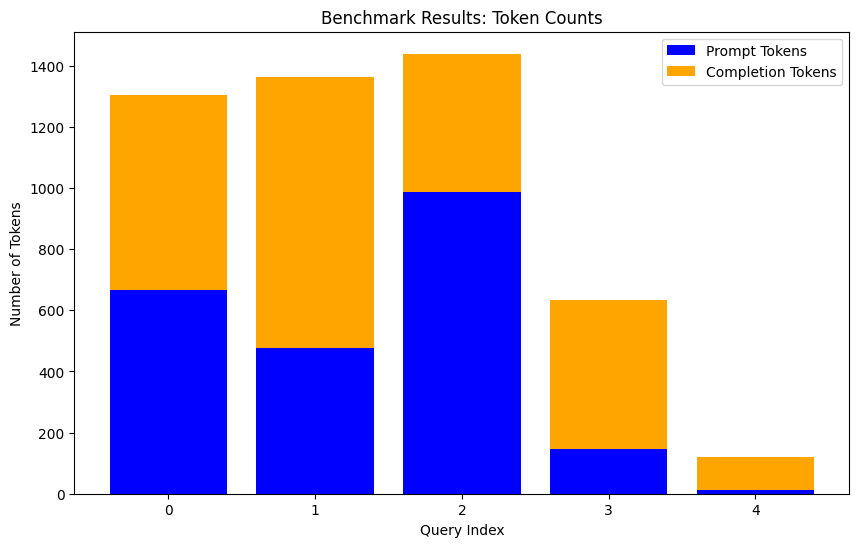

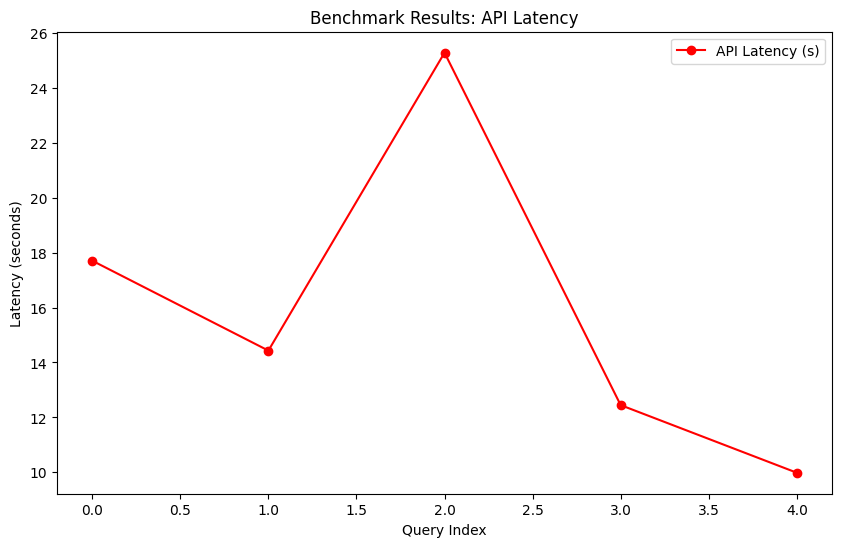

In [24]:
# Plot the benchmark results
plot_benchmark_results(benchmark_results_list)